# 1. Imports & configuration

In [1]:
import os
import time
import zipfile
import urllib.request
from collections import Counter
from typing import List, Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)


# 2. Dataset

In [2]:
DATA_URL = "http://mattmahoney.net/dc/text8.zip"
DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "text8.zip")
TEXT_PATH = os.path.join(DATA_DIR, "text8")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(TEXT_PATH):
  print("Downloading text8...")
  urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
  with zipfile.ZipFile(ZIP_PATH) as zf:
    zf.extractall(DATA_DIR)
  print("Done.")
else:
  print("text8 already present.")

with open(TEXT_PATH, "r") as f:
  raw_text = f.read()

# Set MAX_TOKENS = None to use the full corpus.
MAX_TOKENS: Optional[int] = None

all_raw_tokens = raw_text.split()
if MAX_TOKENS is not None:
  all_raw_tokens = all_raw_tokens[:MAX_TOKENS]

print(f"Corpus tokens: {len(all_raw_tokens):,}")
print("Sample:", " ".join(all_raw_tokens[:20]))


Done.
Corpus tokens: 17,005,207
Sample: anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english


# 3. `Vocabulary` class

In [3]:
class Vocabulary:
  def __init__(
    self,
    tokens: List[str],
    min_count: int = 1,
    subsample_t: float = 1e-5,
    noise_exp: float = 0.75,
    noise_table_size: int = 5_000_000,
    rng: np.random.Generator = RNG,
  ):
    self.rng = rng
    self.subsample_t = subsample_t

    counter = Counter(tokens)
    vocab_words = sorted([w for w, c in counter.items() if c >= min_count])

    self.word2idx: Dict[str, int] = {w: i for i, w in enumerate(vocab_words)}
    self.idx2word: Dict[int, str] = {i: w for w, i in self.word2idx.items()}
    self.size = len(vocab_words)

    total = sum(counter[w] for w in vocab_words)
    self.word_freq = np.array(
      [counter[w] / total for w in vocab_words], dtype=np.float32
    )

    f = self.word_freq
    self.keep_prob = np.minimum(
      1.0, np.sqrt(subsample_t / (f + 1e-10))
    )

    noise_dist = self.word_freq ** noise_exp
    self.noise_dist = noise_dist / noise_dist.sum()

    # Pre-built table for fast negative sampling.
    # According to Mikolov et al. original implementation
    # (see https://github.com/tmikolov/word2vec)
    self._noise_table = rng.choice(
      self.size, size=noise_table_size, p=self.noise_dist
    ).astype(np.int32)
    self._noise_ptr = 0

    print(
      f"Vocabulary: {self.size:,} words "
      f"(min_count={min_count}, subsample_t={subsample_t})"
    )

  def encode(self, tokens: List[str]) -> List[int]:
    return [self.word2idx[w] for w in tokens if w in self.word2idx]

  def subsample(self, int_tokens: List[int]) -> List[int]:
    keep_mask = self.rng.random(len(int_tokens)) < self.keep_prob[int_tokens]
    return [idx for idx, keep in zip(int_tokens, keep_mask) if keep]

  def sample_negatives_batch(self, batch_size: int, k: int) -> np.ndarray:
    needed = batch_size * k
    if self._noise_ptr + needed > len(self._noise_table):
      self._noise_ptr = 0
    out = self._noise_table[self._noise_ptr:self._noise_ptr + needed]
    self._noise_ptr += needed
    return out.reshape(batch_size, k)

  def __len__(self) -> int:
    return self.size


# 4. `word2vec` model class

In [4]:
class Word2Vec:
  def __init__(
    self,
    vocab_size: int,
    embed_dim: int,
    rng: np.random.Generator = RNG,
  ):
    self.vocab_size = vocab_size
    self.embed_dim = embed_dim

    scale = 0.5 / embed_dim
    self.W_in = rng.uniform(-scale, scale, (vocab_size, embed_dim)).astype(
      np.float32
    )
    self.W_out = np.zeros((vocab_size, embed_dim), dtype=np.float32)

    print(
      f"Word2Vec: vocab={vocab_size:,} "
      f"embed_dim={embed_dim} "
    )

  @staticmethod
  def _sigmoid(x: np.ndarray) -> np.ndarray:
    return np.where(
      x >= 0,
      1.0 / (1.0 + np.exp(-x)),
      np.exp(x) / (1.0 + np.exp(x)),
    )

  def train_batch(
    self,
    center_indices: np.ndarray,
    context_indices: np.ndarray,
    neg_indices: np.ndarray,
    lr: float,
  ) -> float:
    center_vecs = self.W_in[center_indices]
    pos_vecs = self.W_out[context_indices]
    neg_vecs = self.W_out[neg_indices]

    pos_scores = np.einsum("bd,bd->b", center_vecs, pos_vecs)
    neg_scores = np.einsum("bd,bkd->bk", center_vecs, neg_vecs)

    pos_sig = self._sigmoid(pos_scores)
    neg_sig = self._sigmoid(neg_scores)

    loss = (
      -np.log(pos_sig + 1e-10)
      - np.log(1.0 - neg_sig + 1e-10).sum(axis=1)
    ).mean()

    grad_center = (
      (pos_sig - 1.0)[:, None] * pos_vecs
      + np.einsum("bk,bkd->bd", neg_sig, neg_vecs)
    )
    grad_pos = (pos_sig - 1.0)[:, None] * center_vecs
    grad_neg = neg_sig[:, :, None] * center_vecs[:, None, :]

    np.add.at(self.W_in, center_indices, -lr * grad_center)
    np.add.at(self.W_out, context_indices, -lr * grad_pos)
    np.add.at(self.W_out, neg_indices.reshape(-1), -lr * grad_neg.reshape(-1, self.embed_dim))

    return float(loss)

  def get_embeddings(self, mode: str = "in") -> np.ndarray:
    if mode == "in":
      W = self.W_in
    elif mode == "out":
      W = self.W_out
    elif mode == "avg":
      W = (self.W_in + self.W_out) / 2.0
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    return W / (norms + 1e-10)

  def __repr__(self) -> str:
    return (
      f"Word2Vec("
      f"vocab_size={self.vocab_size}, "
      f"embed_dim={self.embed_dim})"
    )


# 5. `train()` function

In [5]:
def _generate_pairs(
  corpus: List[int],
  window: int,
  rng: np.random.Generator,
) -> np.ndarray:
  n = len(corpus)
  window_sizes = rng.integers(1, window + 1, size=n)
  pairs = []
  for i, w in enumerate(window_sizes):
    center = corpus[i]
    left = max(0, i - w)
    right = min(n, i + w + 1)
    for j in range(left, right):
      if j != i:
        pairs.append((center, corpus[j]))
  return np.array(pairs, dtype=np.int32)


def train(
  model: Word2Vec,
  vocab: Vocabulary,
  raw_tokens: List[str],
  window: int = 3,
  neg_samples: int = 7,
  epochs: int = 5,
  batch_size: int = 1024,
  lr_init: float = 0.025,
  lr_min: float = 0.003,
  log_every: int = 500,
  rng: np.random.Generator = RNG,
) -> List[float]:
  int_tokens = vocab.encode(raw_tokens)
  subsampled = vocab.subsample(int_tokens)
  print(
    f"Corpus: {len(int_tokens):,} tokens after OOV removal"
    f"        {len(subsampled):,} tokens after sub-sampling "
    f"({100*len(subsampled)/len(int_tokens):.1f}%)"
  )

  print("Building skip-gram pairs ...")
  start = time.time()
  pairs = _generate_pairs(subsampled, window, rng)
  print(f"  {len(pairs):,} pairs generated in {time.time() - start:.1f}s")

  n_pairs = len(pairs)
  steps_per_epoch = n_pairs // batch_size
  total_steps = epochs * steps_per_epoch
  global_step = 0
  loss_history: List[float] = []

  wall_start = time.time()
  print(
    f"Training: epochs={epochs} batch={batch_size} "
    f"neg={neg_samples} window={window} "
    f"lr={lr_init}->{lr_min}"
  )

  for epoch in range(1, epochs + 1):
    ep_start = time.time()
    ep_losses: List[float] = []

    idx = rng.permutation(n_pairs)
    centers = pairs[idx, 0]
    contexts = pairs[idx, 1]

    for step in range(steps_per_epoch):
      s, e = step * batch_size, (step + 1) * batch_size

      progress = global_step / max(total_steps, 1)
      lr = max(lr_min, lr_init * (1.0 - progress))

      negs = vocab.sample_negatives_batch(batch_size, neg_samples)

      loss = model.train_batch(centers[s:e], contexts[s:e], negs, lr)
      ep_losses.append(loss)
      loss_history.append(loss)
      global_step += 1

      if (step + 1) % log_every == 0:
        avg = float(np.mean(ep_losses[-log_every:]))
        done = 100 * (step + 1) / steps_per_epoch
        elapsed = time.time() - ep_start
        print(
          f"  Epoch {epoch}/{epochs} "
          f"[{done:5.1f}%] "
          f"loss={avg:.4f} "
          f"lr={lr:.5f} "
          f"elapsed={elapsed:.0f}s"
        )

    ep_mean = float(np.mean(ep_losses))
    print(
      f"Epoch {epoch}/{epochs} complete -- "
      f"mean_loss={ep_mean:.4f} "
      f"time={time.time() - ep_start:.0f}s"
    )

  print(f"Training complete. Total wall time: {time.time() - wall_start:.0f}s")
  return loss_history


# 6. Build vocabulary, instantiate model, and train

In [6]:
# Hyper-parameters
HP = {
  "min_count": 3,
  "subsample_t": 1e-5,
  "embed_dim": 500,
  "window": 4,
  "neg_samples": 7,
  "epochs": 2,
  "batch_size": 1024,
  "lr_init": 0.025,
  "lr_min": 0.0003,
}

vocab = Vocabulary(
  all_raw_tokens,
  min_count=HP["min_count"],
  subsample_t=HP["subsample_t"],
  rng=RNG,
)

model = Word2Vec(
  vocab_size=len(vocab),
  embed_dim=HP["embed_dim"],
  rng=RNG,
)

loss_history = train(
  model,
  vocab,
  all_raw_tokens,
  window=HP["window"],
  neg_samples=HP["neg_samples"],
  epochs=HP["epochs"],
  batch_size=HP["batch_size"],
  lr_init=HP["lr_init"],
  lr_min=HP["lr_min"],
  rng=RNG,
)


Vocabulary: 100,038 words (min_count=3, subsample_t=1e-05)
Word2Vec: vocab=100,038 embed_dim=500 
Corpus: 16,816,094 tokens after OOV removal        4,775,744 tokens after sub-sampling (28.4%)
Building skip-gram pairs ...
  23,885,953 pairs generated in 24.8s
Training: epochs=2 batch=1024 neg=7 window=4 lr=0.025->0.0003
  Epoch 1/2 [  2.1%] loss=5.3784 lr=0.02473 elapsed=69s
  Epoch 1/2 [  4.3%] loss=4.3244 lr=0.02446 elapsed=132s
  Epoch 1/2 [  6.4%] loss=3.7936 lr=0.02420 elapsed=196s
  Epoch 1/2 [  8.6%] loss=3.5712 lr=0.02393 elapsed=263s
  Epoch 1/2 [ 10.7%] loss=3.4462 lr=0.02366 elapsed=327s
  Epoch 1/2 [ 12.9%] loss=3.3566 lr=0.02339 elapsed=389s
  Epoch 1/2 [ 15.0%] loss=3.2939 lr=0.02312 elapsed=456s
  Epoch 1/2 [ 17.1%] loss=3.2426 lr=0.02286 elapsed=530s
  Epoch 1/2 [ 19.3%] loss=3.2044 lr=0.02259 elapsed=595s
  Epoch 1/2 [ 21.4%] loss=3.1704 lr=0.02232 elapsed=661s
  Epoch 1/2 [ 23.6%] loss=3.1426 lr=0.02205 elapsed=730s
  Epoch 1/2 [ 25.7%] loss=3.1182 lr=0.02179 elapsed=

# 7. Loss curve

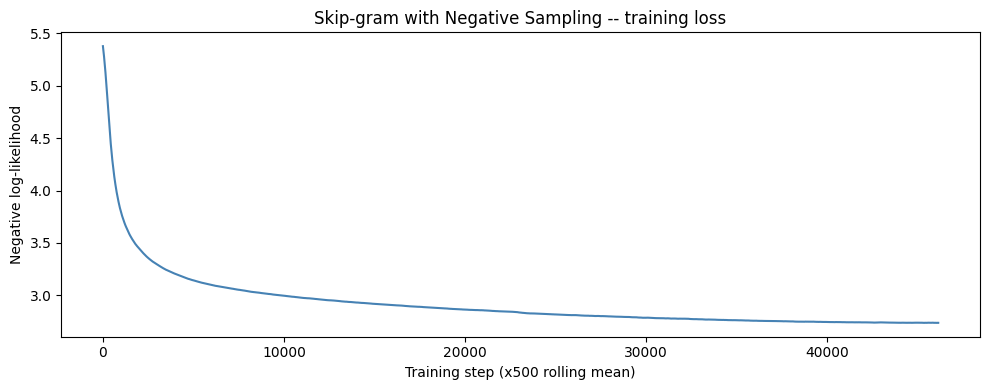

Saved loss_curve.png


In [7]:
def plot_loss(loss_history: List[float], window: int = 500) -> None:
  smooth = np.convolve(loss_history, np.ones(window) / window, mode="valid")
  plt.figure(figsize=(10, 4))
  plt.plot(smooth, linewidth=1.5, color="steelblue")
  plt.xlabel(f"Training step (x{window} rolling mean)")
  plt.ylabel("Negative log-likelihood")
  plt.title("Skip-gram with Negative Sampling -- training loss")
  plt.tight_layout()
  plt.savefig("loss_curve.png", dpi=150)
  plt.show()
  print("Saved loss_curve.png")

plot_loss(loss_history)


# 8. Evaluation of the model

In [9]:
def nearest_neighbours(
  word: str,
  vocab: Vocabulary,
  embeddings: np.ndarray,
  top_k: int = 5,
) -> List[Tuple[str, float]]:
  if word not in vocab.word2idx:
    print(f"  \"{word}\" not in vocabulary.")
    return []
  idx = vocab.word2idx[word]
  sims = embeddings @ embeddings[idx]
  sims[idx] = -1
  top = np.argsort(sims)[::-1][:top_k]
  return [(vocab.idx2word[i], float(sims[i])) for i in top]

def analogy(
  a: str,
  b: str,
  c: str,
  vocab: Vocabulary,
  embeddings: np.ndarray,
  top_k: int = 5,
) -> List[Tuple[str, float]]:
  missing = [w for w in (a, b, c) if w not in vocab.word2idx]
  if missing:
    print(f"  Not in vocab: {missing}")
    return []
  vec = (
    embeddings[vocab.word2idx[a]]
    - embeddings[vocab.word2idx[b]]
    + embeddings[vocab.word2idx[c]]
  )
  vec = vec / (np.linalg.norm(vec) + 1e-10)
  sims = embeddings @ vec
  for w in (a, b, c):
    sims[vocab.word2idx[w]] = -1
  top = np.argsort(sims)[::-1][:top_k]
  return [(vocab.idx2word[i], float(sims[i])) for i in top]

E = model.get_embeddings("avg")

print("=== Nearest neighbours ===")
for w in ["king", "france", "cat", "music", "science"]:
  nn = nearest_neighbours(w, vocab, E, top_k=8)
  if nn:
    print(f"{w:>10}  ->  " + ", ".join(f"{nb}({s:.2f})" for nb, s in nn))

print("=== Analogies ===")
tests = [
  ("king", "man", "woman"),
  ("paris", "france", "berlin")
]
for a, b, c in tests:
  res = analogy(a, b, c, vocab, E, top_k=5)
  if res:
    top = ", ".join(f"{w}({s:.2f})" for w, s in res)
    print(f"{a} - {b} + {c}  ->  {top}")


=== Nearest neighbours ===
      king  ->  emperor(0.97), pope(0.96), viii(0.95), vii(0.95), augustus(0.95), constantine(0.95), prince(0.94), livy(0.94)
    france  ->  spain(0.96), poland(0.96), germany(0.95), hungary(0.95), austria(0.95), italy(0.94), portugal(0.94), russia(0.93)
       cat  ->  winged(0.96), pink(0.95), squirrel(0.94), snakes(0.94), trumpets(0.94), horns(0.94), candy(0.94), stuffed(0.93)
     music  ->  dance(0.93), musical(0.91), style(0.89), genres(0.86), popular(0.86), artists(0.85), genre(0.85), art(0.83)
   science  ->  sciences(0.84), collection(0.83), philosophy(0.81), journal(0.81), journals(0.81), academic(0.79), detailed(0.79), study(0.78)
=== Analogies ===
king - man + woman  ->  reigned(0.86), tenn(0.85), pyrrhus(0.83), dynasty(0.83), antigonus(0.83)
paris - france + berlin  ->  vincennes(0.96), marischal(0.96), rector(0.95), wellesley(0.95), durham(0.95)


# Analyzing results

As can be seen both from loss curve and results, model learns, but it learns mostly contextial (topical) similarity (e.g. "king" <-> "vii" since there are a lot of names like "King Richard VII" etc.) rather than semantic (e.g. "king - man + woman" <-> "queen"). The reason for this is mostly due to relatively small dataset (~17M dataset used in this notebook comparing to original ~1B dataset).